<a href="https://colab.research.google.com/github/SajaZenaty/GSG-CV/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import random
import copy
import time
import numpy as np
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

**Configurations**

In [ ]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
NUM_WORKERS = 0
EPOCHS = 20
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
print("Using device:", DEVICE)

Using device: cuda


In [ ]:
CLASS_NAMES = [
"airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"
]
NUM_CLASSES = len(CLASS_NAMES)
print("Number of classes:", NUM_CLASSES)
for idx, name in enumerate(CLASS_NAMES):
  print(idx, "->", name)

Number of classes: 10
0 -> airplane
1 -> automobile
2 -> bird
3 -> cat
4 -> deer
5 -> dog
6 -> frog
7 -> horse
8 -> ship
9 -> truck


In [ ]:
openml_dataset = fetch_openml(
name="CIFAR_10_small",
version=1,
as_frame=False
)
X_flat = openml_dataset.data
y_raw = openml_dataset.target
print("Data shape:", X_flat.shape)
print("Target shape:", y_raw.shape)
print("Data type:", X_flat.dtype)
print("Target examples:", y_raw[:10])

Data shape: (20000, 3072)
Target shape: (20000,)
Data type: int64
Target examples: ['6' '9' '9' '4' '1' '1' '2' '7' '8' '3']


In [ ]:
y = y_raw.astype(np.int64)
print("Unique labels:", np.unique(y))
print("Number of labels:", len(np.unique(y)))

Unique labels: [0 1 2 3 4 5 6 7 8 9]
Number of labels: 10


In [ ]:
if X_flat.shape[1] != 3072:
  raise ValueError("Expected each CIFAR-10 image to have 3072 features.")
X_images = X_flat.reshape(-1, 3, 32, 32)
X_images = X_images.transpose(0, 2, 3, 1)
X_images = np.clip(X_images, 0, 255).astype(np.uint8)
print("Image array shape:", X_images.shape)
print("Image data type:", X_images.dtype)
print("Minimum pixel value:", X_images.min())
print("Maximum pixel value:", X_images.max())

Image array shape: (20000, 32, 32, 3)
Image data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255


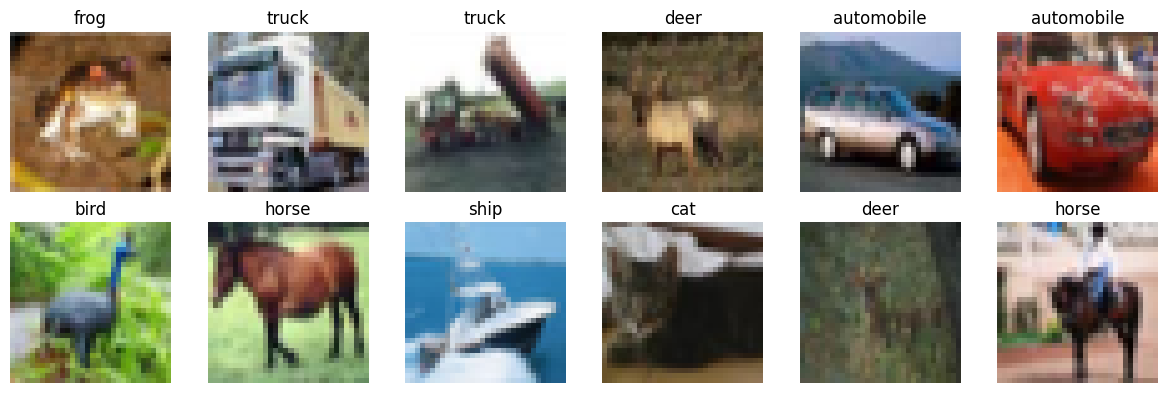

In [ ]:
def show_raw_examples(images, labels, class_names, num_images=12):
  plt.figure(figsize=(12, 4))
  for i in range(num_images):
    image = images[i]
    label = labels[i]
    plt.subplot(2, num_images // 2, i + 1)
    plt.imshow(image)
    plt.title(class_names[label])
    plt.axis("off")
  plt.tight_layout()
  plt.show()

show_raw_examples(X_images, y, CLASS_NAMES, num_images=12)

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
X_images,
y,
test_size=0.30,
random_state=SEED,
stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
X_temp,
y_temp,
test_size=0.50,
random_state=SEED,
stratify=y_temp
)
print("Training images:", X_train.shape)
print("Validation images:", X_val.shape)
print("Test images:", X_test.shape)
print("Training labels:", y_train.shape)
print("Validation labels:", y_val.shape)
print("Test labels:", y_test.shape)

Training images: (14000, 32, 32, 3)
Validation images: (3000, 32, 32, 3)
Test images: (3000, 32, 32, 3)
Training labels: (14000,)
Validation labels: (3000,)
Test labels: (3000,)


In [ ]:
def print_class_distribution(labels, class_names, title):
  counts = np.bincount(labels, minlength=len(class_names))
  print(title)
  print("-" * len(title))
  for idx, count in enumerate(counts):
    print(f"{class_names[idx]}: {count}")
  print()

print_class_distribution(y_train, CLASS_NAMES, "Training set distribution")
print_class_distribution(y_val, CLASS_NAMES, "Validation set distribution")
print_class_distribution(y_test, CLASS_NAMES, "Test set distribution")

Training set distribution
-------------------------
airplane: 1404
automobile: 1382
bird: 1422
cat: 1411
deer: 1399
dog: 1356
frog: 1421
horse: 1401
ship: 1417
truck: 1387

Validation set distribution
---------------------------
airplane: 300
automobile: 296
bird: 305
cat: 303
deer: 300
dog: 290
frog: 305
horse: 300
ship: 304
truck: 297

Test set distribution
---------------------
airplane: 301
automobile: 296
bird: 305
cat: 302
deer: 300
dog: 291
frog: 304
horse: 300
ship: 304
truck: 297



In [ ]:
def compute_channel_mean_std(images):
  images_float = images.astype(np.float32) / 255.0
  mean = images_float.mean(axis=(0, 1, 2))
  std = images_float.std(axis=(0, 1, 2))
  return mean, std

CIFAR10_MEAN, CIFAR10_STD = compute_channel_mean_std(X_train)
CIFAR10_MEAN = tuple(CIFAR10_MEAN.tolist())
CIFAR10_STD = tuple(CIFAR10_STD.tolist())
print("Training set mean:", CIFAR10_MEAN)
print("Training set std:", CIFAR10_STD)

Training set mean: (0.4938886761665344, 0.48401275277137756, 0.44863152503967285)
Training set std: (0.2474883496761322, 0.24400481581687927, 0.2622087597846985)


In [ ]:
class OpenMLCIFAR10Dataset(Dataset):
  def __init__(self, images, labels, transform=None):
    self.images = images
    self.labels = labels.astype(np.int64)
    self.transform = transform
  def __len__(self):
    return len(self.images)
  def __getitem__(self, index):
    image = self.images[index]
    label = self.labels[index]
    image = Image.fromarray(image, mode="RGB")
    if self.transform is not None:
      image = self.transform(image)
    return image, label

## Basic Preprocessing

In [ ]:
basic_train_transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

basic_eval_transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

In [ ]:
augmented_train_transform = transforms.Compose([
transforms.RandomCrop(32, padding=4),
transforms.RandomHorizontalFlip(p=0.5),
transforms.ToTensor(),
transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

augmented_eval_transform = transforms.Compose([
transforms.ToTensor(),
transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])

In [ ]:
augmented_train_transform_with_color = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [ ]:
augmented_train_transform_with_erasing = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
    transforms.RandomErasing(p=0.25)
])

In [ ]:
class OpenCVPreprocess:
  def __init__(self, use_clahe=True, use_sharpen=True):
    self.use_clahe = use_clahe
    self.use_sharpen = use_sharpen
  def __call__(self, image):
    """
    Input:
    image: PIL image in RGB format
    Output:
    PIL image in RGB format after OpenCV preprocessing
    """
    img = np.array(image)
    if self.use_clahe:
      lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
      l_channel, a_channel, b_channel = cv2.split(lab)
      clahe = cv2.createCLAHE(
      clipLimit=2.0,
      tileGridSize=(4, 4)
      )
      l_channel = clahe.apply(l_channel)
      lab = cv2.merge((l_channel, a_channel, b_channel))
      img = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

      if self.use_sharpen:
        blurred = cv2.GaussianBlur(img, (3, 3), 0)
        img = cv2.addWeighted(img, 1.2, blurred, -0.2, 0)
      img = np.clip(img, 0, 255).astype(np.uint8)
      return Image.fromarray(img, mode="RGB")

In [ ]:
rich_train_transform = transforms.Compose([
OpenCVPreprocess(use_clahe=True, use_sharpen=True),
transforms.RandomCrop(32, padding=4),
transforms.RandomHorizontalFlip(p=0.5),
transforms.ToTensor(),
transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])
rich_eval_transform = transforms.Compose([
OpenCVPreprocess(use_clahe=True, use_sharpen=True),
transforms.ToTensor(),
transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

In [ ]:
def denormalize_tensor(image_tensor, mean=CIFAR10_MEAN,
std=CIFAR10_STD):
  mean = torch.tensor(mean, dtype=image_tensor.dtype).view(3, 1, 1)
  std = torch.tensor(std, dtype=image_tensor.dtype).view(3, 1, 1)
  image = image_tensor.cpu() * std + mean
  image = torch.clamp(image, 0, 1)
  return image

/tmp/ipykernel_1736/281536021.py:4: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  raw_image = Image.fromarray(raw_image_array, mode="RGB")


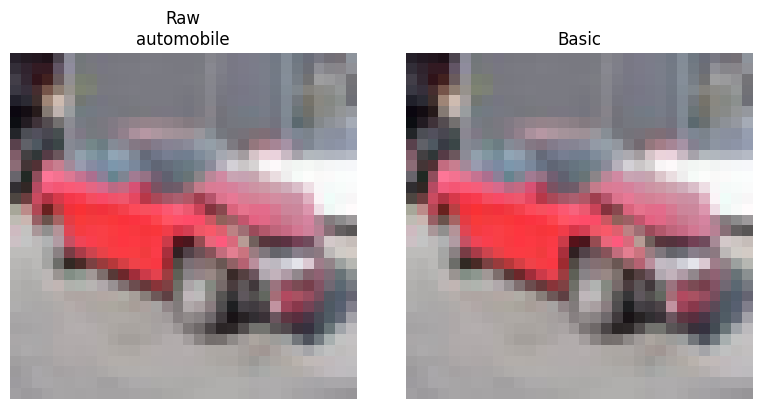

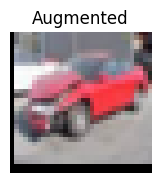

/tmp/ipykernel_1736/3410894394.py:28: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  return Image.fromarray(img, mode="RGB")


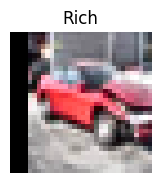

In [ ]:
def show_transform_comparison(images, labels, index, transform_dict,class_names):
  raw_image_array = images[index]
  label = labels[index]
  raw_image = Image.fromarray(raw_image_array, mode="RGB")
  num_versions = 1 + len(transform_dict)
  plt.figure(figsize=(4 * num_versions, 4))
  plt.subplot(1, num_versions, 1)
  plt.imshow(raw_image_array)
  plt.title("Raw\n" + class_names[label])
  plt.axis("off")
  for i, (name, transform) in enumerate(transform_dict.items(),start=2):
    transformed = transform(raw_image)
    if isinstance(transformed, torch.Tensor):
      transformed = denormalize_tensor(transformed)
      transformed = transformed.permute(1, 2, 0).numpy()
    plt.subplot(1, num_versions, i)
    plt.imshow(transformed)
    plt.title(name)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

transform_dict = {
  "Basic": basic_train_transform,
  "Augmented": augmented_train_transform,
  "Rich": rich_train_transform
  }
show_transform_comparison(
  images=X_train,
  labels=y_train,
  index=10,
  transform_dict=transform_dict,
  class_names=CLASS_NAMES
  )

In [ ]:
def create_dataloaders(train_transform, eval_transform):
  train_dataset = OpenMLCIFAR10Dataset(
  images=X_train,
  labels=y_train,
  transform=train_transform
  )
  val_dataset = OpenMLCIFAR10Dataset(
  images=X_val,
  labels=y_val,
  transform=eval_transform
  )
  test_dataset = OpenMLCIFAR10Dataset(
  images=X_test,
  labels=y_test,
  transform=eval_transform
  )
  pin_memory = True if DEVICE.type == "cuda" else False
  train_loader = DataLoader(
  train_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  num_workers=NUM_WORKERS,
  pin_memory=pin_memory
  )
  val_loader = DataLoader(
  val_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=pin_memory
  )
  test_loader = DataLoader(
  test_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False,
  num_workers=NUM_WORKERS,
  pin_memory=pin_memory
  )
  return train_loader, val_loader, test_loader

In [ ]:
train_loader, val_loader, test_loader = create_dataloaders(
train_transform=basic_train_transform,
eval_transform=basic_eval_transform
)
images_batch, labels_batch = next(iter(train_loader))
print("Image batch shape:", images_batch.shape)
print("Label batch shape:", labels_batch.shape)
print("Image batch dtype:", images_batch.dtype)
print("Label batch dtype:", labels_batch.dtype)

/tmp/ipykernel_1736/414830897.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image batch dtype: torch.float32
Label batch dtype: torch.int64


In [ ]:
class MiniAlexNet(nn.Module):
  def __init__(self, num_classes=10):
    super(MiniAlexNet, self).__init__()
    self.features = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=3, padding=1),
    nn.BatchNorm2d(64),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(64, 128, kernel_size=3, padding=1),
    nn.BatchNorm2d(128),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2),
    nn.Conv2d(128, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.Conv2d(256, 256, kernel_size=3, padding=1),
    nn.BatchNorm2d(256),
    nn.ReLU(inplace=True),
    nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.classifier = nn.Sequential(
    nn.Flatten(),
    nn.Linear(256 * 4 * 4, 512),
    nn.ReLU(inplace=True),
    nn.Dropout(p=0.5),
    nn.Linear(512, num_classes)
    )
  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x

In [ ]:
model = MiniAlexNet(num_classes=NUM_CLASSES).to(DEVICE)
print(model)

MiniAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): ReLU(inplace=True)
    (14): MaxP

In [ ]:
dummy_input = torch.randn(4, 3, 32, 32).to(DEVICE)
with torch.no_grad():
  dummy_output = model(dummy_input)
print("Input shape:", dummy_input.shape)
print("Output shape:", dummy_output.shape)

Input shape: torch.Size([4, 3, 32, 32])
Output shape: torch.Size([4, 10])


In [ ]:
def count_trainable_parameters(model):
  return sum(parameter.numel() for parameter in model.parameters() if
  parameter.requires_grad)

num_parameters = count_trainable_parameters(model)
print("Trainable parameters:", num_parameters)

Trainable parameters: 3065098


***Why does the final layer have 10 output values?***
- Because we have ten classes and every value shows the score of being the class of this predicted image .

In [ ]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  running_correct = 0
  running_total = 0
  for images, labels in dataloader:
    images = images.to(device)
    labels = labels.to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    _, predicted = torch.max(outputs, dim=1)
    batch_size = labels.size(0)
    running_loss += loss.item() * batch_size
    running_correct += (predicted == labels).sum().item()
    running_total += batch_size
  epoch_loss = running_loss / running_total
  epoch_accuracy = running_correct / running_total
  return epoch_loss, epoch_accuracy

In [ ]:
def evaluate(model, dataloader, criterion, device):
  model.eval()
  running_loss = 0.0
  running_correct = 0
  running_total = 0
  all_labels = []
  all_predictions = []
  with torch.no_grad():
    for images, labels in dataloader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      loss = criterion(outputs, labels)
      _, predicted = torch.max(outputs, dim=1)
      batch_size = labels.size(0)
      running_loss += loss.item() * batch_size
      running_correct += (predicted == labels).sum().item()
      running_total += batch_size
      all_labels.extend(labels.cpu().numpy())
      all_predictions.extend(predicted.cpu().numpy())

  epoch_loss = running_loss / running_total
  epoch_accuracy = running_correct / running_total
  return epoch_loss, epoch_accuracy, np.array(all_labels),np.array(all_predictions)

In [ ]:
def train_model(train_loader, val_loader, experiment_name,epochs=EPOCHS):
  model = MiniAlexNet(num_classes=NUM_CLASSES).to(DEVICE)
  criterion = nn.CrossEntropyLoss()
  optimizer = optim.Adam(
  model.parameters(),
  lr=LEARNING_RATE,
  weight_decay=WEIGHT_DECAY
  )
  best_val_accuracy = 0.0
  best_model_state = copy.deepcopy(model.state_dict())
  history = {
  "train_loss": [],
  "train_accuracy": [],
  "val_loss": [],
  "val_accuracy": []
  }
  print()
  print("Starting experiment:", experiment_name)
  print("-" * 70)
  for epoch in range(epochs):
    start_time = time.time()
    train_loss, train_accuracy = train_one_epoch(
    model=model,
    dataloader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=DEVICE
    )
    val_loss, val_accuracy, _, _ = evaluate(
    model=model,
    dataloader=val_loader,
    criterion=criterion,
    device=DEVICE
    )
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)
    if val_accuracy > best_val_accuracy:
      best_val_accuracy = val_accuracy
      best_model_state = copy.deepcopy(model.state_dict())
    elapsed = time.time() - start_time
    print(
    f"Epoch [{epoch + 1}/{epochs}] "
    f"Train Loss: {train_loss:.4f} "
    f"Train Acc: {train_accuracy:.4f} "
    f"Val Loss: {val_loss:.4f} "
    f"Val Acc: {val_accuracy:.4f} "
    f"Time: {elapsed:.1f}s"
    )
  model.load_state_dict(best_model_state)
  print("-" * 70)
  print(f"Best validation accuracy for {experiment_name}:{best_val_accuracy:.4f}")
  return model, history, best_val_accuracy

In [ ]:
def plot_history(history, title):
  epochs_range = range(1, len(history["train_loss"]) + 1)
  plt.figure(figsize=(8, 5))
  plt.plot(epochs_range, history["train_loss"], label="Training Loss")
  plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
  plt.xlabel("Epoch")
  plt.ylabel("Loss")
  plt.title(title + " - Loss")
  plt.legend()
  plt.grid(True)
  plt.show()
  plt.figure(figsize=(8, 5))
  plt.plot(epochs_range, history["train_accuracy"], label="Training Accuracy")
  plt.plot(epochs_range, history["val_accuracy"], label="Validation Accuracy")
  plt.xlabel("Epoch")
  plt.ylabel("Accuracy")
  plt.title(title + " - Accuracy")
  plt.legend()
  plt.grid(True)
  plt.show()

In [ ]:
# EXPERIMENTS = {
# "basic": {
# "train_transform": basic_train_transform,
# "eval_transform": basic_eval_transform,
# "description": "Basic tensor conversion and normalization"
# },
# "augmented": {
# "train_transform": augmented_train_transform,
# "eval_transform": augmented_eval_transform,
# "description": "Random crop and horizontal flip during training"
# },
# "rich": {
# "train_transform": rich_train_transform,
# "eval_transform": rich_eval_transform,
# "description": "OpenCV preprocessing plus training augmentation"
# }
# }
# print("Available experiments:")
# for name, config in EXPERIMENTS.items():
#   print(f"{name:10s}: {config['description']}")
EXPERIMENTS["random_erasing"] = {
    "train_transform": augmented_train_transform_with_erasing,
    "eval_transform": augmented_eval_transform,
    "description": "Random crop, horizontal flip, and RandomErasing"
}

In [ ]:
# For a full comparison:
experiments_to_run = ["random_erasing"]
# For a faster CPU run, you may use this instead:
# experiments_to_run = ["rich"]

/tmp/ipykernel_1736/414830897.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")



Starting experiment: random_erasing
----------------------------------------------------------------------
Epoch [1/20] Train Loss: 2.0823 Train Acc: 0.2476 Val Loss: 1.7877 Val Acc: 0.3543 Time: 9.5s
Epoch [2/20] Train Loss: 1.7234 Train Acc: 0.3572 Val Loss: 1.5053 Val Acc: 0.4240 Time: 9.5s
Epoch [3/20] Train Loss: 1.5775 Train Acc: 0.4110 Val Loss: 1.3462 Val Acc: 0.4873 Time: 9.1s
Epoch [4/20] Train Loss: 1.4847 Train Acc: 0.4482 Val Loss: 1.2846 Val Acc: 0.5177 Time: 9.4s
Epoch [5/20] Train Loss: 1.3851 Train Acc: 0.4951 Val Loss: 1.1758 Val Acc: 0.5577 Time: 9.5s
Epoch [6/20] Train Loss: 1.3247 Train Acc: 0.5172 Val Loss: 1.0923 Val Acc: 0.5960 Time: 11.3s
Epoch [7/20] Train Loss: 1.2531 Train Acc: 0.5539 Val Loss: 1.0533 Val Acc: 0.6070 Time: 8.9s
Epoch [8/20] Train Loss: 1.2136 Train Acc: 0.5703 Val Loss: 1.0077 Val Acc: 0.6360 Time: 9.5s
Epoch [9/20] Train Loss: 1.1684 Train Acc: 0.5831 Val Loss: 0.9954 Val Acc: 0.6400 Time: 9.4s
Epoch [10/20] Train Loss: 1.1095 Train Acc: 0

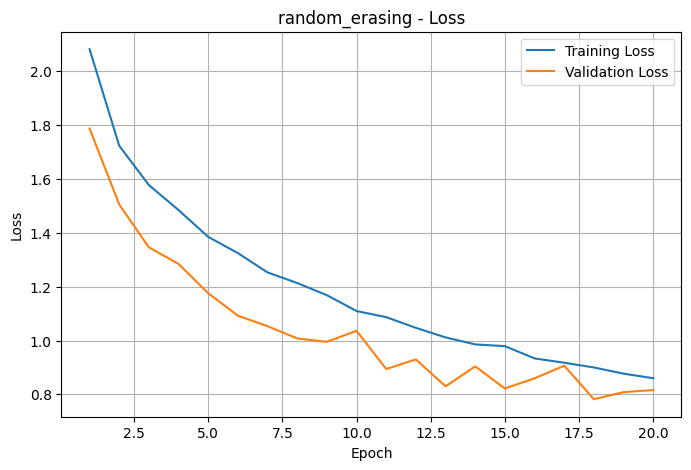

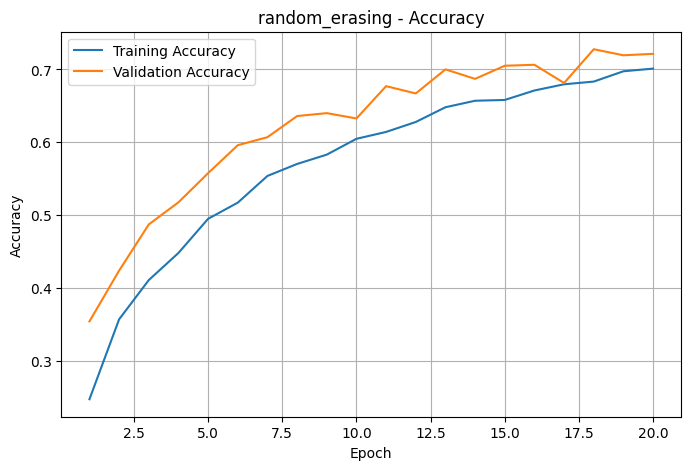

In [ ]:
results = {}
criterion = nn.CrossEntropyLoss()
for experiment_name in experiments_to_run:
  config = EXPERIMENTS[experiment_name]
  train_loader, val_loader, test_loader = create_dataloaders(
  train_transform=config["train_transform"],
  eval_transform=config["eval_transform"]
  )
  model, history, best_val_accuracy = train_model(
  train_loader=train_loader,
  val_loader=val_loader,
  experiment_name=experiment_name,
  epochs=EPOCHS
  )
  test_loss, test_accuracy, test_labels, test_predictions = evaluate(
  model=model,
  dataloader=test_loader,
  criterion=criterion,
  device=DEVICE
  )
  results[experiment_name] = {
  "model": model,
  "history": history,
  "best_val_accuracy": best_val_accuracy,
  "test_loss": test_loss,
  "test_accuracy": test_accuracy,
  "test_labels": test_labels,
  "test_predictions": test_predictions
  }
  print()
  print(f"Test accuracy for {experiment_name}: {test_accuracy:.4f}")
  plot_history(history, title=experiment_name)

In [ ]:
print()
print("Final comparison")
print("-" * 80)
print(f"{'Experiment':<15} {'Best Val Acc':<15} {'Test Loss':<15} {'TestAcc':<15}")
print("-" * 80)
for experiment_name, result in results.items():
  print(
  f"{experiment_name:<15} "
  f"{result['best_val_accuracy']:<15.4f} "
  f"{result['test_loss']:<15.4f} "
  f"{result['test_accuracy']:<15.4f}"
  )
  print("-" * 80)


Final comparison
--------------------------------------------------------------------------------
Experiment      Best Val Acc    Test Loss       TestAcc        
--------------------------------------------------------------------------------
random_erasing  0.7277          0.8148          0.7133         
--------------------------------------------------------------------------------


In [ ]:
best_experiment_name = max(
results,
key=lambda name: results[name]["test_accuracy"]
)
best_result = results[best_experiment_name]
best_model = best_result["model"]
print("Best experiment:", best_experiment_name)
print("Best test accuracy:", best_result["test_accuracy"])

Best experiment: random_erasing
Best test accuracy: 0.7133333333333334


In [ ]:
model_path = f"best_mini_alexnet_{best_experiment_name}.pt"
torch.save(best_model.state_dict(), model_path)
print("Saved model to:", model_path)

Saved model to: best_mini_alexnet_random_erasing.pt


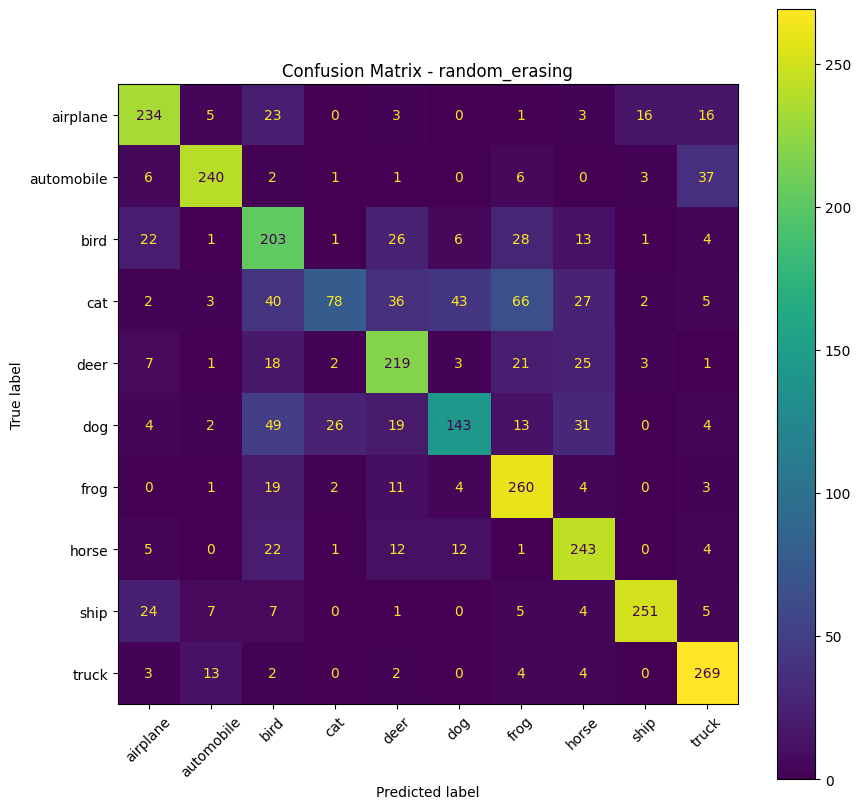

In [ ]:
cm = confusion_matrix(
best_result["test_labels"],
best_result["test_predictions"]
)
disp = ConfusionMatrixDisplay(
confusion_matrix=cm,
display_labels=CLASS_NAMES
)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title(f"Confusion Matrix - {best_experiment_name}")
plt.show()

In [ ]:
report = classification_report(
best_result["test_labels"],
best_result["test_predictions"],
target_names=CLASS_NAMES,
zero_division=0
)
print(report)

              precision    recall  f1-score   support

    airplane       0.76      0.78      0.77       301
  automobile       0.88      0.81      0.84       296
        bird       0.53      0.67      0.59       305
         cat       0.70      0.26      0.38       302
        deer       0.66      0.73      0.70       300
         dog       0.68      0.49      0.57       291
        frog       0.64      0.86      0.73       304
       horse       0.69      0.81      0.74       300
        ship       0.91      0.83      0.87       304
       truck       0.77      0.91      0.83       297

    accuracy                           0.71      3000
   macro avg       0.72      0.71      0.70      3000
weighted avg       0.72      0.71      0.70      3000



In [ ]:
def show_most_confused_pairs(cm, class_names, top_k=5):
  cm_errors = cm.copy()
  np.fill_diagonal(cm_errors, 0)
  pairs = []
  for true_idx in range(cm_errors.shape[0]):
    for pred_idx in range(cm_errors.shape[1]):
      count = cm_errors[true_idx, pred_idx]
      if count > 0:
        pairs.append((count, true_idx, pred_idx))
  pairs = sorted(pairs, reverse=True)
  print(f"Top {top_k} confused pairs")
  print("-" * 40)
  for count, true_idx, pred_idx in pairs[:top_k]:
    true_name = class_names[true_idx]
    pred_name = class_names[pred_idx]
    print(f"True: {true_name:12s} Predicted: {pred_name:12s} Count:{count}")

  show_most_confused_pairs(cm, CLASS_NAMES, top_k=5)

In [ ]:
def get_test_samples_with_predictions(test_loader, model, device,
  max_samples=300):
  model.eval()
  images_list = []
  labels_list = []
  predictions_list = []
  with torch.no_grad():
    for images, labels in test_loader:
      images_device = images.to(device)
      outputs = model(images_device)
      _, predictions = torch.max(outputs, dim=1)
      images_list.append(images.cpu())
      labels_list.append(labels.cpu())
      predictions_list.append(predictions.cpu())
      if sum(len(x) for x in labels_list) >= max_samples:
        break
  images = torch.cat(images_list, dim=0)[:max_samples]
  labels = torch.cat(labels_list, dim=0)[:max_samples]
  predictions = torch.cat(predictions_list, dim=0)[:max_samples]
  return images, labels, predictions

In [ ]:
def show_predictions(images, labels, predictions, class_names,correct=True, num_images=12):
  if correct:
    selected_indices = torch.where(labels == predictions)[0]
    title = "Correct Predictions"
  else:
    selected_indices = torch.where(labels != predictions)[0]
    title = "Incorrect Predictions"

  # Limit the number of selected images to 'num_images'
  selected_indices = selected_indices[:num_images]

  if len(selected_indices) == 0:
    print("No examples found.")
    return

  # Ensure there are enough images to fill the grid, otherwise adjust num_images
  if len(selected_indices) < num_images:
    num_images = len(selected_indices)

  plt.figure(figsize=(12, 4))
  for i, idx in enumerate(selected_indices):
    image = denormalize_tensor(images[idx])
    image = image.permute(1, 2, 0).numpy()
    true_label = class_names[labels[idx].item()]
    predicted_label = class_names[predictions[idx].item()]
    plt.subplot(2, num_images // 2, i + 1)
    plt.imshow(image)
    plt.title(f"T: {true_label}\nP: {predicted_label}")
    plt.axis("off")
  plt.suptitle(title)
  plt.tight_layout()
  plt.show()

/tmp/ipykernel_1736/414830897.py:11: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  image = Image.fromarray(image, mode="RGB")


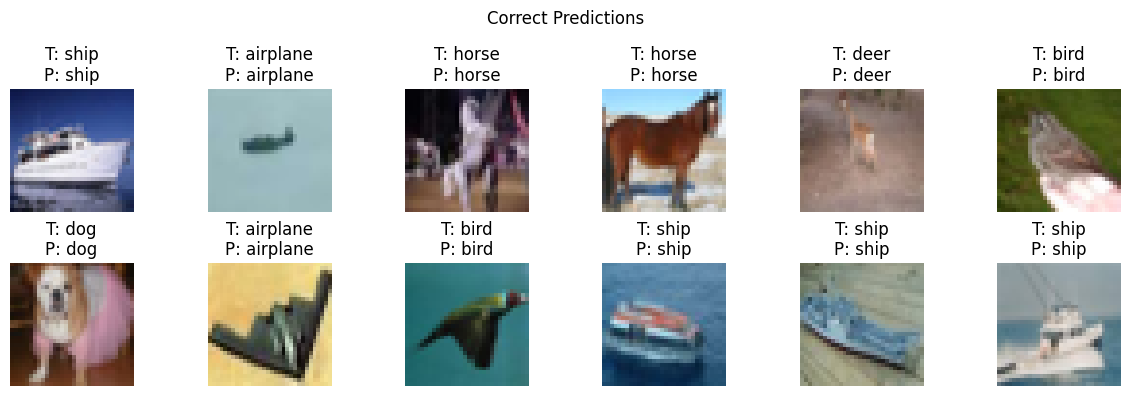

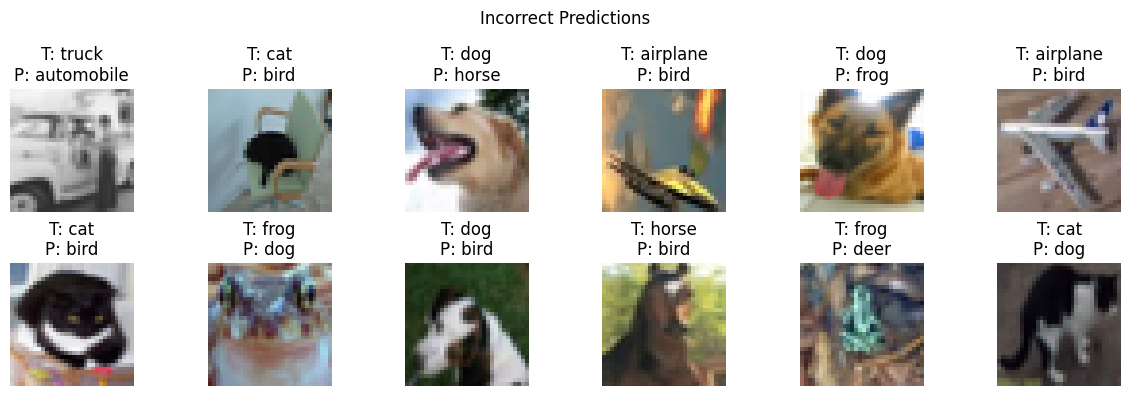

In [ ]:
best_eval_transform = EXPERIMENTS[best_experiment_name]["eval_transform"]
best_train_transform = EXPERIMENTS[best_experiment_name]["train_transform"]
_, _, best_test_loader = create_dataloaders(
    train_transform=best_train_transform,
    eval_transform=best_eval_transform
)
sample_images, sample_labels, sample_predictions = get_test_samples_with_predictions(
    test_loader=best_test_loader,
    model=best_model,
    device=DEVICE,
    max_samples=300
)

show_predictions(
    images=sample_images,
    labels=sample_labels,
    predictions=sample_predictions,
    class_names=CLASS_NAMES,
    correct=True,
    num_images=12
)

show_predictions(
    images=sample_images,
    labels=sample_labels,
    predictions=sample_predictions,
    class_names=CLASS_NAMES,
    correct=False,
    num_images=12
)

###Result When we have 5 epochs

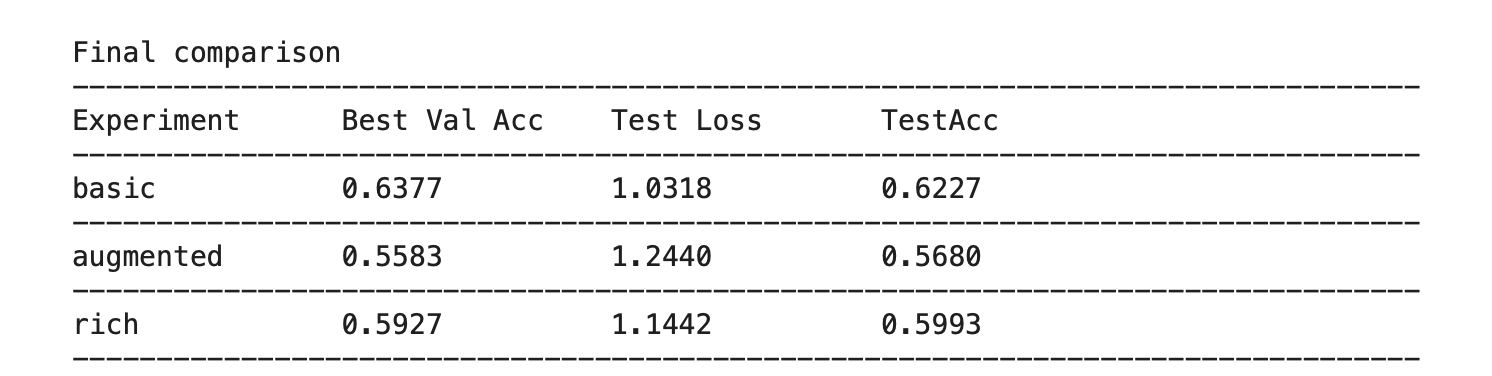

1. Did the best pipeline after 5 epochs remain the best pipeline after more
epochs?
- No, for 5 epochs the best pipeline is basic pipeline , but in 20 epochs is augumented pipeline .
2. Did augmentation help more when the model trained for longer?
- yes , so the augumented is the best pipeline in the 20 epochs experiment .
3. Draw the table above after the 20 epochs.

###Result when epochs 20

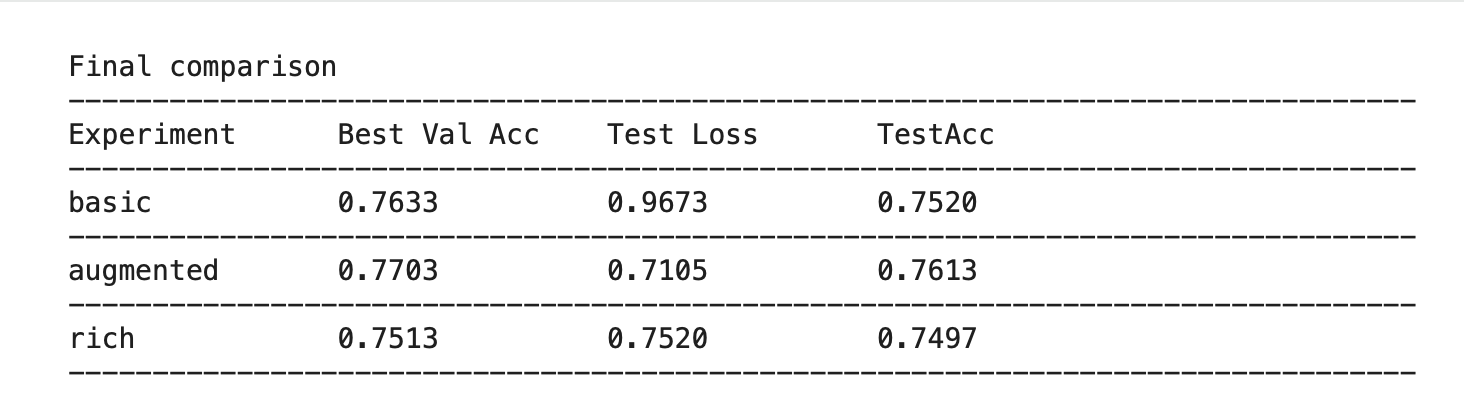

###Result for ColorJitter

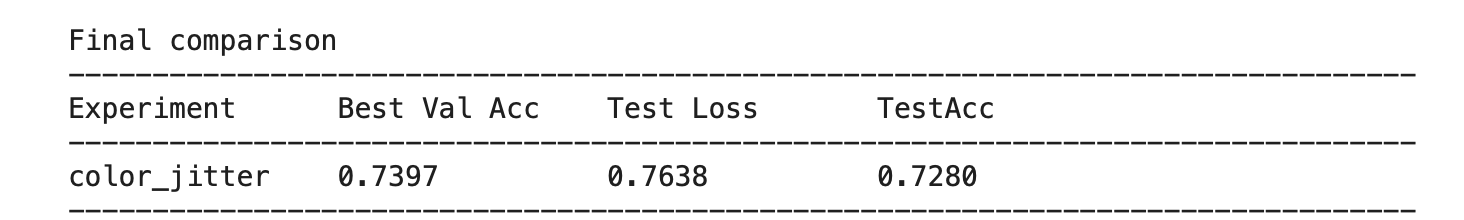

**The ColorJitter has less accuracy than previous experiments**


###Result for RandomErasing

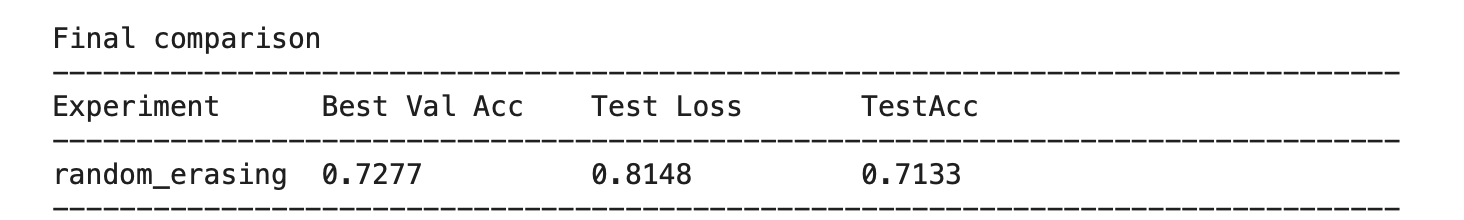

**The RandomErasing has less accuracy than previous experiments**
